# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import torch
import torch.nn as nn
import scipy
from torch.autograd import Variable
from torchinfo import summary
from tqdm import tqdm
from sklearn.metrics import r2_score
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Problem Setup

In [2]:
data = scipy.io.loadmat("data.mat")
x = data['x']
f_fun = data['f']
u_data = data['u']

# data = scipy.io.loadmat("data_noise.mat")
# x = data['x']
# f_fun = data['f']
# u_data = data['u_noise']
# u_data[0] = 0
# u_data[-1] = 0

In [3]:
a = x[0,0]
b = x[-1,0]
Ne = x.shape[0]-1

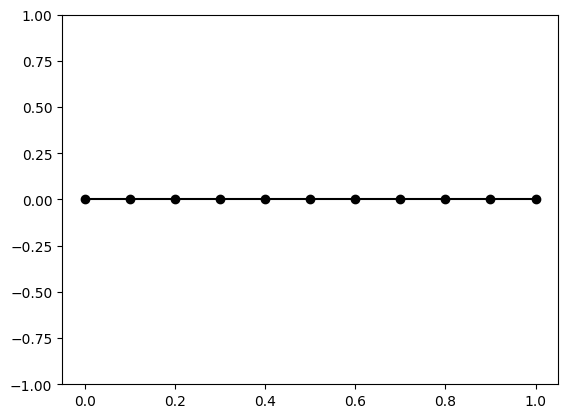

In [4]:
x_pred = np.arange(0,b+(b-a)/100,1/100).reshape(-1,1)
y = x*0

plt.figure()
plt.plot(x,y,'-k')
plt.plot(x,y,'ok')
plt.ylim([-1, 1])
plt.show()

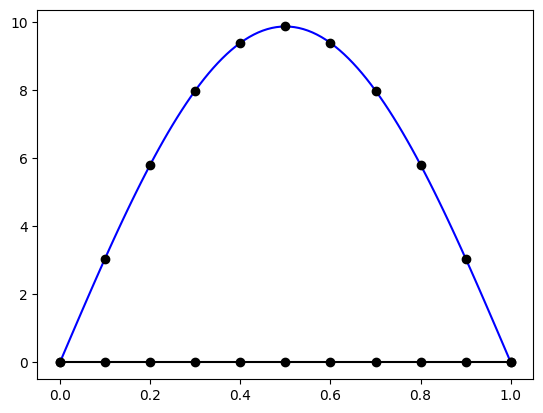

In [5]:
f_fun_fig = math.pi**2*np.sin(math.pi*x_pred)

plt.figure()
plt.plot(x,y,'-k')
plt.plot(x,y,'ok')
plt.plot(x_pred,f_fun_fig,'-b')
plt.plot(x,f_fun,'ok')
plt.show()

# Create Neural Net

In [6]:
class Tanh(nn.Module):
    def forward(self, x):
        return torch.tanh(x)

In [7]:
class create_net(nn.Module):
    def __init__(self):
        super(create_net, self).__init__()
        self.hidden_layer1 = nn.Linear(1,50)
        self.hidden_layer2 = nn.Linear(50,50)
        self.output_layer = nn.Linear(50,1)
        self.activation = Tanh()

    def forward(self, x):
        inputs = x
        layer1_out = self.hidden_layer1(inputs)
        layer1_out = self.activation(layer1_out)
        layer2_out = self.hidden_layer2(layer1_out)
        layer2_out = self.activation(layer2_out)     
        output = self.output_layer(layer2_out)
        return output

In [8]:
model = create_net()
model = model.to(device)
summary(model, x.shape)

Layer (type:depth-idx)                   Output Shape              Param #
create_net                               [11, 1]                   --
├─Linear: 1-1                            [11, 50]                  100
├─Tanh: 1-2                              [11, 50]                  --
├─Linear: 1-3                            [11, 50]                  2,550
├─Tanh: 1-4                              [11, 50]                  --
├─Linear: 1-5                            [11, 1]                   51
Total params: 2,701
Trainable params: 2,701
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.03
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.01
Estimated Total Size (MB): 0.02

# Create Loss Function

In [9]:
x_ode = Variable(torch.from_numpy(x).float(), requires_grad=True).to(device)
f_fun_ode = Variable(torch.from_numpy(f_fun).float(), requires_grad=True).to(device)
u_data_ode = Variable(torch.from_numpy(u_data).float(), requires_grad=True).to(device)

In [10]:
def loss(x, model, u_data):
        
    u_pred = model(x)
    
    loss = torch.nn.MSELoss()

    total_loss = loss(u_pred, u_data)

    return total_loss

# Run training

In [11]:
epochs = 1000
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)
pbar = tqdm(range(epochs), desc='description')

description:   0%|          | 0/1000 [00:00<?, ?it/s]

In [12]:
def closure():
    if torch.is_grad_enabled():
        optimizer.zero_grad()
    
    total_loss = loss(x_ode, model, u_data_ode)
    
    if total_loss.requires_grad:
        total_loss.backward()
    
    return total_loss

In [13]:
for i in pbar:
    
    optimizer.step(closure)
    
    total_loss = loss(x_ode, model, u_data_ode)
    
    pbar.set_description("total_loss: %.2e " % (total_loss.cpu().detach().numpy()))

total_loss: 2.62e-06 : 100%|██████████| 1000/1000 [00:01<00:00, 550.79it/s]


# Compare to actual

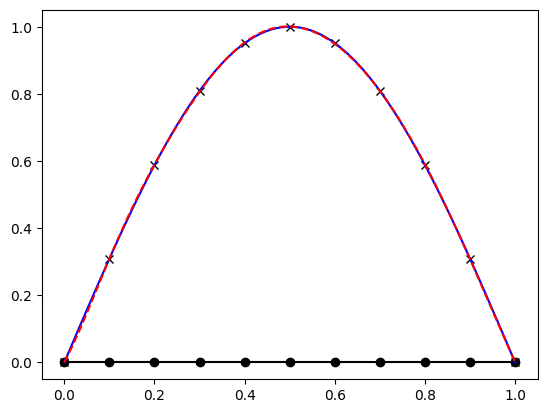

In [14]:
x_pred_ode = Variable(torch.from_numpy(x_pred).float(), requires_grad=True).to(device)

with torch.no_grad():
    u_pred = model(x_pred_ode)
    
u_actual = np.sin(math.pi*x_pred)

plt.figure()
plt.plot(x,y,'-k')
plt.plot(x,y,'ok')
plt.plot(x,u_data,'xk')
plt.plot(x_pred,u_actual,'-b')
plt.plot(x_pred,u_pred.cpu().numpy(),'--r')
plt.show()

In [15]:
r2_score(u_pred.cpu().numpy(), u_actual)

0.9999079648273068